In [1]:
!pip install pyDOE

  Preparing metadata (setup.py) ... done
  Created wheel for pyDOE: filename=pyDOE-0.3.8-py3-none-any.whl size=18170 sha256=152abbb8fd6dbb1767fd04c57c9e6c7ba18e516aba29842bb3bcb32964ac0d6d
  Stored in directory: /root/.cache/pip/wheels/84/20/8c/8bd43ba42b0b6d39ace1219d6da1576e0dac81b12265c4762e
Successfully built pyDOE


In [2]:
import torch
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import Dataset, DataLoader, ConcatDataset, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d
from pyDOE import lhs

from IPython.display import clear_output
import time
from datetime import datetime, timedelta
import gc

np.random.seed(0)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Problema inverso de estimación de función

Consideremos el problema de condución de calor 1D en régimen transiente sobre un material con propiedades termofísicas $\rho,c,k$ y longitud $L$, dado por las siguientes ecuaciones de gobierno escritas en configuración adimensional:

$$\frac{\partial u}{\partial\tau}=\frac{\partial^2 u}{\partial\xi^2},\quad\xi\in(0,1),\,\tau\in(0,\tau_f]$$

$$-\frac{\partial u}{\partial\xi}(0,\tau)=q^{\ast}(\tau),\quad\tau\in(0,\tau_f]$$

$$\frac{\partial u}{\partial\xi}(1,\tau)=0,\quad\tau\in(0,\tau_f]$$
$$u(\xi,0)=u_0,\quad\xi\in[0,1]$$

donde:
$$u=\frac{T}{\Delta T},\quad q^{\ast}=\frac{q}{q_{ref}},\quad q_{ref}=k\frac{\Delta T}{L},\quad\tau=\frac{\alpha t}{L^2},\quad\xi=\frac{x}{L}$$

Se resuelve mediante PINN el problema de estimar el flujo de calor desconocido $q^{\ast}(\tau)$ que actúa en la frontera izquierda ($\xi=0$) del dominio. Para ello, se implementa la posibilidad de estimar tal función mediante un polinomio de grado $N$ o mediante una red neuronal complementaria.

In [3]:
 # Neural Network
class PINN_Module(nn.Module):

    def __init__(self, model_parameters):
        super(PINN_Module, self).__init__()
        self.Device = model_parameters["Device"]
        self.LowerBounds = model_parameters["LowerBounds"]
        self.UpperBounds = model_parameters["UpperBounds"]
        self.ThermalConductivity = model_parameters["ThermalConductivity"]
        self.ThermalDiffusivity = model_parameters["ThermalDiffusivity"]
        self.HeatFluxLeft = model_parameters["HeatFluxLeft"]
        self.InputDimensions = model_parameters["InputDimensions"]
        self.OutputDimensions = model_parameters["OutputDimensions"]
        self.NumberOfNeurons = model_parameters["NumberOfNeurons"]
        self.NumberOfHiddenLayers = model_parameters["NumberOfHiddenLayers"]
        self.ActivationFunction = model_parameters["ActivationFunction"]
        self.InputLayer = nn.Linear(self.InputDimensions, self.NumberOfNeurons)
        self.HiddenLayers = nn.ModuleList(
            [nn.Linear(self.NumberOfNeurons, self.NumberOfNeurons) for _ in range(self.NumberOfHiddenLayers - 1)])
        self.OutputLayer = nn.Linear(self.NumberOfNeurons, self.OutputDimensions)

        self.init_xavier()


    def forward(self, x):
        lb = self.LowerBounds
        ub = self.UpperBounds
        x = 2*(x - lb)/(ub - lb) - 1
        output = self.ActivationFunction(self.InputLayer(x))
        for k, l in enumerate(self.HiddenLayers):
            output = self.ActivationFunction(l(output))
        output = self.OutputLayer(output)
        return output


    def init_xavier(self):

        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                g = nn.init.calculate_gain('tanh')
                torch.nn.init.xavier_uniform_(m.weight, gain=g)
                # torch.nn.init.xavier_normal_(m.weight, gain=g)
                m.bias.data.fill_(0)

        self.apply(init_weights)


    def internalEnergyBalanceResidue(self, X, T):
        alpha = self.ThermalDiffusivity

        diff_T = torch.autograd.grad(T, X, create_graph=True, grad_outputs=torch.ones_like(T))[0]
        Tx = diff_T[:, 0:1].clone()
        Tt = diff_T[:, 1:2].clone()

        Txx = torch.autograd.grad(Tx, X, create_graph=True, grad_outputs=torch.ones_like(Tx), retain_graph=True)[0][:, 0:1].clone()

        residue = Tt - alpha * Txx
        return residue


    def boundaryConditionNeumannResidue(self, X, T):
        k = self.ThermalConductivity
        q_left = self.HeatFluxLeft  # ← should be computed inside closure, avoid reuse

        Tx = torch.autograd.grad(
            T, X,
            create_graph=True,
            grad_outputs=torch.ones_like(T),
            retain_graph=True
        )[0][:, 0:1].clone()

        residue = k * Tx + q_left
        return residue


## Problem data

In [4]:
# Properties of pure solid aluminium
k_true = 210.0 # W/(m K)
c_true = 900.0 # J/(kg K)
rho_true = 2700.0 #kg/m^3
alpha_true = k_true/(rho_true*c_true)

# Boundaries of space and time domains
ti, tf = 0, 1000.0 # s
xi, xf = 0, 0.3 # m

ki, kt = 1, 1
k = k_true
rho = rho_true
c = c_true
alpha = alpha_true
q_ref = 1
DT = 1
nd = True
if nd:
    kx = 1 / xf
    kt = alpha_true / xf**2
    alpha = 1
    k = 1
    rho = 1
    c = 1
    DT = 1000
    q_ref = k_true*DT/xf

lb = torch.tensor([kx*xi, kt*ti])
ub = torch.tensor([kx*xf, kt*tf])

# Initial and boundary temperatures
q_left_true = lambda x: 1e6 / q_ref * np.sin(2 * np.pi * x / tf)
T0 = lambda x: 1/DT * np.full((x.shape[0], ), 600)

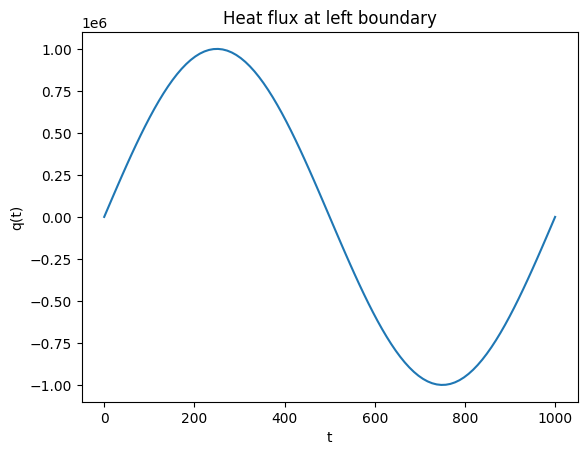

In [5]:
# Imposed heat flux at left boundary
plt.plot(np.linspace(ti, tf, 100), q_ref*q_left_true(np.linspace(ti, tf, 100)))
plt.xlabel('t')
plt.ylabel('q(t)')
plt.title('Heat flux at left boundary')
plt.show()

## Ground-truth solution (FEM)

In [6]:
nnod = 100
nele = nnod - 1
x_fem = np.linspace(xi, xf, nnod)

nsteps = 100
t_fem = np.linspace(ti, tf, nsteps)
dt = t_fem[1] - t_fem[0]

M = np.zeros((nnod, nnod))
K = np.zeros((nnod, nnod))
for i in range(nele):
    hk = np.abs(x_fem[i+1] - x_fem[i])
    ke = k_true*np.array([[1/hk, -1/hk], [-1/hk, 1/hk]])
    K[i:i+2, i:i+2] = K[i:i+2, i:i+2] + ke
    me = rho_true*c_true*np.array([[hk/3, hk/6], [hk/6, hk/3]])
    M[i:i+2, i:i+2] = M[i:i+2, i:i+2] + me

A = M/dt + K
TT = np.zeros((nnod, nsteps))
F = np.zeros((nnod, nsteps))
F[0, :] = q_ref * q_left_true(t_fem)
TT[:, 0] = DT * T0(x_fem)
for i in range(nsteps-1):
    Ti = TT[:, i:i+1]
    b = np.dot(M/dt, Ti) + F[:, i+1:i+2]
    T = np.linalg.solve(A, b)
    TT[:, i+1:i+2] = T

# Grid for evaluation the exact solution
ms_x, ms_t = np.meshgrid(x_fem, t_fem)
x_test = np.ravel(ms_x).reshape(-1, 1)
t_test = np.ravel(ms_t).reshape(-1, 1)

T_ex_grid = TT.reshape(ms_x.shape)

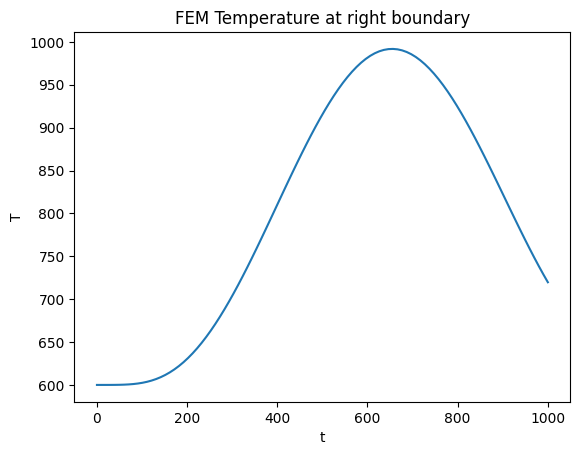

In [7]:
# Temperature data at the right boundary
plt.plot(t_fem, TT[-1, :])
plt.xlabel('t')
plt.ylabel('T')
plt.title('FEM Temperature at right boundary')
plt.show()

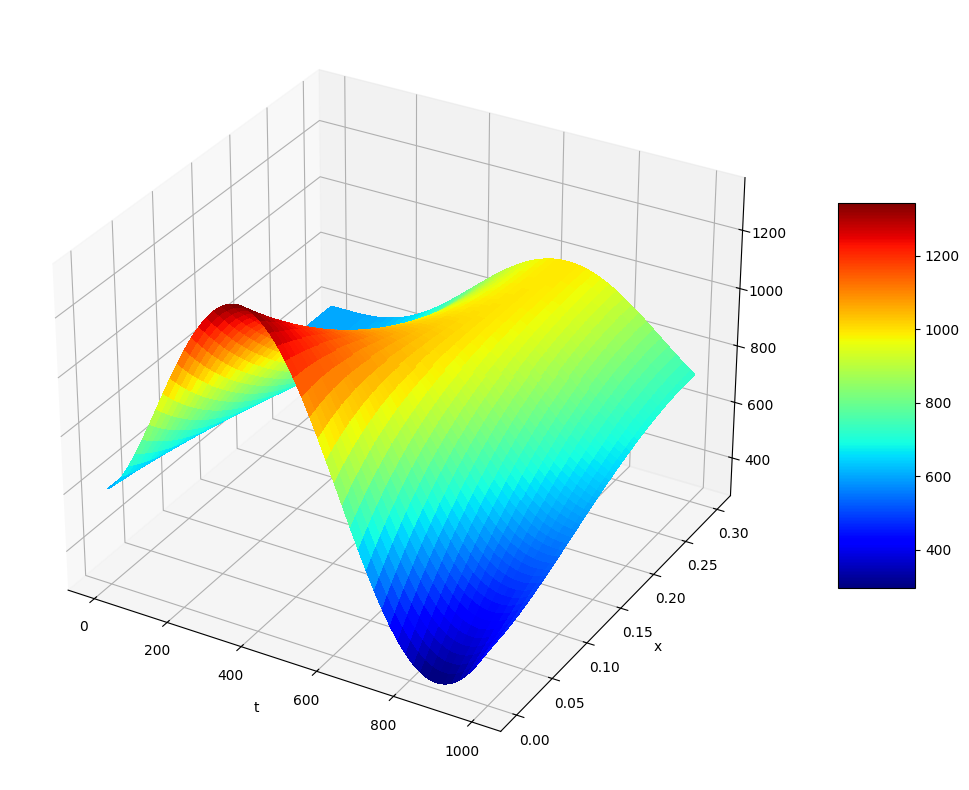

In [8]:
# Plot the exact temperature distribution
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection = '3d')
#ax.view_init(elev=20, azim=-90)
surf1 = ax.plot_surface(ms_t, ms_x, T_ex_grid.T, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf1, shrink=0.5, aspect=5)
plt.xlabel('t')
plt.ylabel('x')
plt.show()

## Datasets (collocation points and labelled data points)

In [9]:
# Generate equispaced tensors for both space and time domains to pick from
x_tensor = torch.linspace(lb[0], ub[0], 10000, device=device)
t_tensor = torch.linspace(lb[1], ub[1], 10000, device=device)

# Number of collocation points
N_dom = 10000 # Number of collocation points for evaluating the residuals
N_bc = 2000 # Number of collocation points for computing the boundary conditions
N_ic = 3000 # Number of collocation points for computing the initial condition
N_data = 1000 # Number of labelled data points

# Train, validation and testing sets
tags = ["Domain", "BoundaryConditionsLeft", "BoundaryConditionsRight", "InitialCondition"]
isData = True

# Initialize list of dataset objects
ds = []

In [10]:
## Collocation points for evaluating the residual of the governing PDE

# Generate collocation points within the domain using Latin Hypercube Sampling (LHS) strategy
X_dom = (lb + (ub - lb)*lhs(2, N_dom)).to(torch.float32).to(device)
y_dom = torch.zeros((N_dom, 1), device=device)

ds.append(TensorDataset(X_dom, y_dom))

/tmp/ipython-input-10-406105958.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_dom = (lb + (ub - lb)*lhs(2, N_dom)).to(torch.float32).to(device)


In [11]:
## Collocation points for evaluating the boundary and initial conditions

# Generate random collocation points for the left boundary (Neumann)
idx_bc = np.random.choice(t_tensor.size()[0], N_bc, replace=False)
t_bc_l = t_tensor[idx_bc].view(-1, 1)
x_bc_l = lb[0]*torch.ones((N_bc, 1), device=device)
X_bc_l = torch.cat([x_bc_l, t_bc_l], axis=1)
y_bc_l = torch.full((N_bc, 1), 0.)
ds.append(TensorDataset(X_bc_l, y_bc_l))

# Generate random collocation points for the right boundary (Dirichlet)
idx_bc = np.random.choice(t_tensor.size()[0], N_bc, replace=False)
t_bc_r = t_tensor[idx_bc].view(-1, 1)
x_bc_r = ub[0]*torch.ones((N_bc, 1), device=device)
X_bc_r = torch.cat([x_bc_r, t_bc_r], axis=1)
temp_r = np.interp(1/kt * t_tensor.cpu(), t_fem, 1/DT * TT[-1, :])
temp_r0 = temp_r[idx_bc].reshape(-1, 1)
temp_r = temp_r0 + 0.02*np.max(temp_r0)*np.random.normal(size=(N_bc, 1))
y_bc_r = torch.from_numpy(temp_r).to(torch.float32).to(device)
ds.append(TensorDataset(X_bc_r, y_bc_r))

# Generate collocation points for the initial condition
idx_ic = np.random.choice(x_tensor.size()[0], N_ic, replace=False)
x_ic = x_tensor[idx_ic].view(-1, 1)
t_ic = lb[1]*torch.ones((N_ic, 1), device=device)
X_ic = torch.cat([x_ic, t_ic], axis=1)
T_ic = T0(x_ic.cpu())
y_ic = torch.from_numpy(T_ic).to(torch.float32).view(-1, 1).to(device)
ds.append(TensorDataset(X_ic, y_ic))

In [12]:
# Generate syntetic temperature labelled data
if isData:
    tags.append("LabelledData")
    omega = 0.02
    sensor_loc = [0.1, 0.2]
    x_data, t_data, T_data = [], [], []
    for loc in sensor_loc:
        idx_data = np.random.choice(x_tensor.size()[0], N_data, replace=False)
        x_data.append(torch.full((N_data, 1), kx*loc, device=device))
        t_data.append(t_tensor[idx_data].view(-1, 1))
        idx_fem = x_fem==loc
        TT_loc = np.interp(1/kt * t_tensor[idx_data].cpu(), t_fem, 1/DT * TT[idx_fem, :].flatten())
        TT_loc_noisy = TT_loc.reshape(N_data, 1) + omega*np.max(TT_loc)*np.random.normal(size=(N_data, 1))
        T_data.append(torch.from_numpy(TT_loc_noisy).to(torch.float32).to(device))

    X_data = torch.cat([torch.cat(x_data, axis=0), torch.cat(t_data, axis=0)], axis=1)
    y_data = torch.cat(T_data, axis=0)
    ds.append(TensorDataset(X_data, y_data))


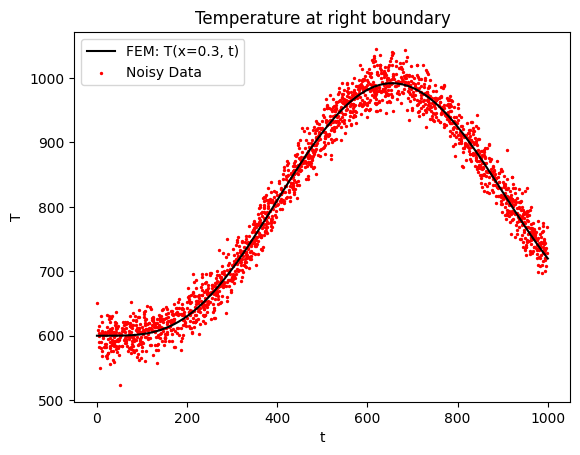

In [13]:
plt.plot(t_fem, TT[-1, :], label=f'FEM: T(x={xf}, t)', c='k')
plt.scatter(1/kt * t_bc_r.cpu().numpy(), DT * temp_r, s=2, label='Noisy Data', c='r')
plt.xlabel('t')
plt.ylabel('T')
plt.title('Temperature at right boundary')
plt.legend()
plt.show()

In [14]:
# Dictionary of dataset objects
datasets = dict(zip(tags, ds))

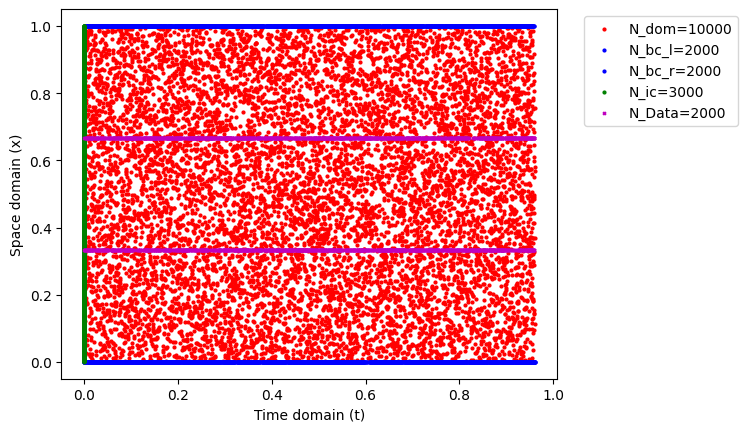

In [15]:
# Plot the locations of the collocation points in the space-time domain
X_dom_train = (datasets["Domain"][:][0]).data.cpu().numpy()
X_bc_l_train = (datasets["BoundaryConditionsLeft"][:][0]).data.cpu().numpy()
X_bc_r_train = (datasets["BoundaryConditionsRight"][:][0]).data.cpu().numpy()
X_ic_train = (datasets["InitialCondition"][:][0]).data.cpu().numpy()
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(X_dom_train[:, 1:2], X_dom_train[0:, 0:1], s=4, c='r', label=f'N_dom={len(X_dom_train)}')
ax.scatter(X_bc_l_train[:, 1:2], X_bc_l_train[:, 0:1], s=4, c='b', label=f'N_bc_l={len(X_bc_l_train)}')
ax.scatter(X_bc_r_train[:, 1:2], X_bc_r_train[:, 0:1], s=4, c='b', label=f'N_bc_r={len(X_bc_r_train)}')
ax.scatter(X_ic_train[:, 1:2], X_ic_train[:, 0:1], s=4, c='g', label=f'N_ic={len(X_ic_train)}')
if isData:
    X_data_train = (datasets["LabelledData"][:][0]).data.cpu().numpy()
    y_data_train = (datasets["LabelledData"][:][1]).data.cpu().numpy()
    ax.scatter(X_data_train[:, 1:2], X_data_train[:, 0:1], s=4, c='m', label=f'N_Data={len(X_data_train)}', marker='x')
ax.legend()
plt.xlabel('Time domain (t)')
plt.ylabel('Space domain (x)')
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

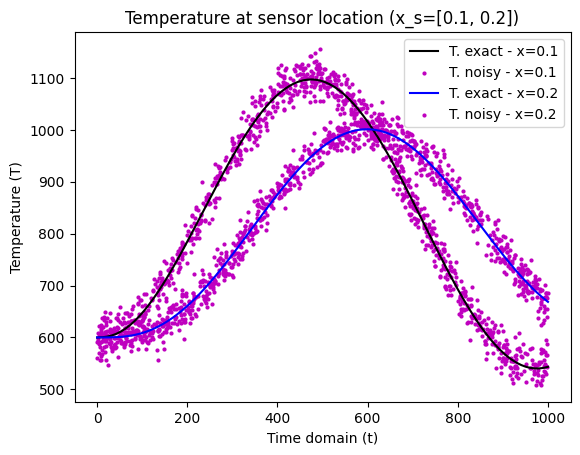

In [16]:
if isData:
    colors = ['k', 'b', 'r', 'g']
    fig = plt.figure()
    ax = fig.add_subplot(111)
    for i, sensor in enumerate(sensor_loc):
        t_data_loc = np.linspace(ti, tf, N_data).reshape(-1, 1)
        x_data_loc = np.full((N_data, 1), sensor)
        T_ex = np.interp(t_data_loc.flatten(), t_fem, TT[x_fem==sensor_loc[i], :].flatten()) #T_exact(x_data_loc, t_data_loc)
        ax.plot(t_data_loc, T_ex, c=colors[i], label=f'T. exact - x={sensor}')
        ax.scatter(1/kt*X_data_train[N_data*i:N_data*(i+1), 1:2], DT*y_data_train[N_data*i:N_data*(i+1)], s=4, c='m', label=f'T. noisy - x={sensor}')

    ax.legend()
    plt.xlabel('Time domain (t)')
    plt.ylabel('Temperature (T)')
    plt.title(f'Temperature at sensor location (x_s={sensor_loc})')
    plt.show()

## Main execution

In [17]:
class NeuralNet(nn.Module):

    def __init__(self, params):
        super(NeuralNet, self).__init__()
        self.LowerBounds = params["LowerBounds"]
        self.UpperBounds = params["UpperBounds"]
        self.InputDimensions = params["InputDimensions"]
        self.OutputDimensions = params["OutputDimensions"]
        self.NumberOfNeurons = params["NumberOfNeurons"]
        self.NumberOfHiddenLayers = params["NumberOfHiddenLayers"]
        self.ActivationFunction = params["ActivationFunction"]
        self.HiddenLayers = nn.ModuleList(
            [nn.Linear(self.NumberOfNeurons, self.NumberOfNeurons) for _ in range(self.NumberOfHiddenLayers - 1)])
        self.InputLayer = nn.Linear(self.InputDimensions, self.NumberOfNeurons)
        self.OutputLayer = nn.Linear(self.NumberOfNeurons, self.OutputDimensions)
        self.init_xavier()

    def forward(self, X):
        lb = self.LowerBounds
        ub = self.UpperBounds
        x = 2 * (X - self.LowerBounds[1]) / (self.UpperBounds[1] - self.LowerBounds[1]) - 1
        output = self.ActivationFunction(self.InputLayer(x))
        for k, l in enumerate(self.HiddenLayers):
            output = self.ActivationFunction(l(output))
        output = self.OutputLayer(output)
        return output

    def init_xavier(self):

        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                g = nn.init.calculate_gain('tanh')
                torch.nn.init.xavier_uniform_(m.weight, gain=g)
                # torch.nn.init.xavier_normal_(m.weight, gain=g)
                m.bias.data.fill_(0)

        self.apply(init_weights)

In [18]:
class Polynom(nn.Module):

    def __init__(self, params):
        super(Polynom, self).__init__()
        num_params = params["NumberOfParameters"]
        self.LowerBounds = params["LowerBounds"]
        self.UpperBounds = params["UpperBounds"]
        self.params = nn.ParameterList([
            nn.Parameter(torch.randn(1)) for _ in range(num_params)
        ])

    def forward(self, X):

        coeffs = (self.params).to(device)
        m = len(coeffs)

        x = 2 * (X - self.LowerBounds[1]) / (self.UpperBounds[1] - self.LowerBounds[1]) - 1
        powers = torch.arange(m, device=X.device).view(1, -1)  # Shape: (1, m)
        terms = x ** powers  # Shape: (N, m) if X is (N, 1)
        p = sum([terms[:, i:i+1] * coeffs[i] for i in range(m)])

        return p

In [19]:
polynom_params = {
    "NumberOfParameters": 6,
    "LowerBounds": lb.to(device),
    "UpperBounds": ub.to(device)
}
polynom = Polynom(polynom_params)

In [20]:
p_init = []
for i, p in enumerate(polynom.parameters()):
    print(f'p[{i}]: ', p.item())
    p_init.append(p.item())

p[0]:  0.23556265234947205
p[1]:  -0.1402437686920166
p[2]:  0.00420716218650341
p[3]:  0.436565101146698
p[4]:  -1.254381537437439
p[5]:  0.31989970803260803


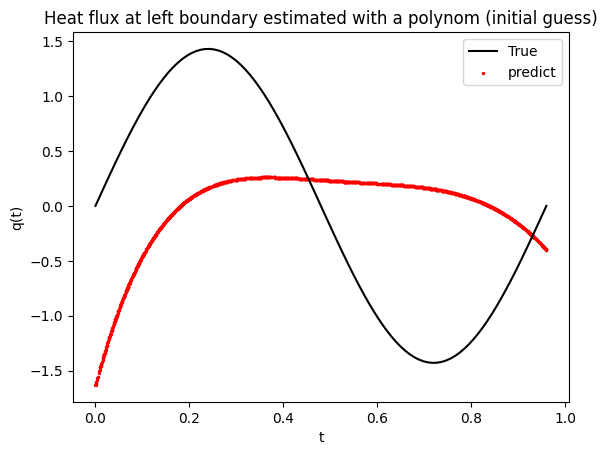

In [21]:
q_left_pred = polynom(t_bc_l.to(device))
plt.plot(kt*t_fem, q_left_true(t_fem), c='k', label='True')
plt.scatter(t_bc_l.detach().cpu().numpy(), q_left_pred.detach().cpu().numpy(), s=2, c='r', label='predict')
plt.xlabel('t')
plt.ylabel('q(t)')
plt.title('Heat flux at left boundary estimated with a polynom (initial guess)')
plt.legend()
plt.show()

In [22]:
class Sin(nn.Module):
    def __init__(self, ):
        super().__init__()

    def forward(self, x):
        return torch.sin(x)

In [23]:
nn_params = {
    "LowerBounds": lb.to(device),
    "UpperBounds": ub.to(device),
    "InputDimensions": 1,
    "OutputDimensions": 1,
    "NumberOfNeurons": 10,
    "NumberOfHiddenLayers": 3,
    "ActivationFunction": nn.ReLU()
}
nn_model = NeuralNet(nn_params).to(device)

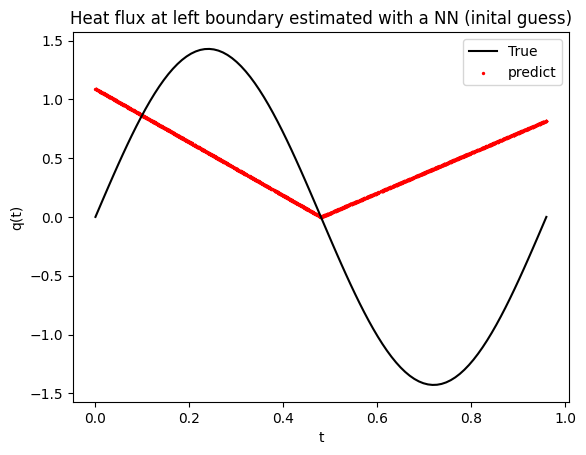

In [24]:
q_left_pred = nn_model(t_bc_l.to(device))
plt.plot(kt*t_fem, q_left_true(t_fem), c='k', label='True')
plt.scatter(t_bc_l.detach().cpu().numpy(), q_left_pred.detach().cpu().numpy(), s=2, c='r', label='predict')
plt.xlabel('t')
plt.ylabel('q(t)')
plt.title('Heat flux at left boundary estimated with a NN (inital guess)')
plt.legend()
plt.show()

In [25]:
# Choose an approximator for the heat flux (a neural network or a polynom)
model_as = 'nn' #options: 'polynom' or 'nn'
if model_as=='polynom':
    q_left_model = polynom
elif model_as=='nn':
    q_left_model = nn_model
else:
    raise ValueError('model_as must be "polynom" or "nn"')

In [26]:
# Input dictionary for model instance
model_parameters = {
    "Device": device,
    "LowerBounds": lb.to(device),
    "UpperBounds": ub.to(device),
    "ThermalConductivity": k,
    "ThermalDiffusivity": alpha,
    "HeatFluxLeft": None, #It will be assigned during training
    "InputDimensions": 2,
    "OutputDimensions": 1,
    "NumberOfNeurons": 20,
    "NumberOfHiddenLayers": 4,
    "ActivationFunction": nn.Tanh()
}

In [27]:
# Model construction
torch.manual_seed(10)
model = PINN_Module(model_parameters).to(device)

In [28]:
# Fitting stage
t0 = datetime.now()
data_time_now = datetime.now().strftime("%d%m%Y_%H%M%S")

epochs = 5000
loss_fn = nn.MSELoss()
trainable_params = list(model.parameters()) + list(q_left_model.parameters())
optimizer_name = 'LBFGS' #options: Adam or LBFGS
if optimizer_name=='Adam':
    optimizer = torch.optim.Adam(
        trainable_params,
        lr=0.001,
        weight_decay=1e-3)
elif optimizer_name=='LBFGS':
    optimizer = torch.optim.LBFGS(
        trainable_params,
        lr=0.8,
        max_iter=1,
        max_eval=50000,
        line_search_fn="strong_wolfe",
        tolerance_change=1.0 * np.finfo(float).eps
    )
loss_train = []
loss_train_dom = []
loss_train_bc_l = []
loss_train_bc_r = []
loss_train_ic = []
loss_train_data = []
train_keys = ['Overall', 'Domain', 'BC_left', 'BC_right', 'IC']
if isData:
    train_keys.append('Data')

for epoch in range(epochs):

    def closure():
        optimizer.zero_grad()
        loss = 0
        for tag in tags:
            X_raw = (datasets[tag][:][0])
            y = (datasets[tag][:][1]).to(device)
            if tag=='Domain':
                X = X_raw.to(device).clone().detach().requires_grad_(True)
                T = model(X)
                y_hat = model.internalEnergyBalanceResidue(X, T)
                loss_tag = loss_fn(y_hat, y)
                loss = loss + loss_tag

            elif tag=='BoundaryConditionsLeft':
                X = X_raw.to(device).clone().detach().requires_grad_(True)
                T = model(X)
                model.HeatFluxLeft = q_left_model(X[:, 1:2])
                y_hat = model.boundaryConditionNeumannResidue(X, T)
                loss_tag = loss_fn(y_hat, y)
                loss = loss + loss_tag

            else:
                X = X_raw.to(device)
                T = model(X)
                loss_tag = loss_fn(T, y)
                loss = loss + loss_tag

        loss.backward(retain_graph=True)
        return loss

    optimizer.step(closure)

    loss_list = []
    for tag in tags:
        X_raw = (datasets[tag][:][0])
        y = (datasets[tag][:][1]).to(device)
        if tag=='Domain':
            X = X_raw.to(device).clone().detach().requires_grad_(True)
            T = model(X)
            y_hat = model.internalEnergyBalanceResidue(X, T)
            loss = loss_fn(y_hat, y)
            loss_list.append(loss)

        elif tag=='BoundaryConditionsLeft':
            X = X_raw.to(device).clone().detach().requires_grad_(True)
            T = model(X)
            model.HeatFluxLeft = q_left_model(X[:, 1:2])
            y_hat = model.boundaryConditionNeumannResidue(X, T)
            loss = loss_fn(y_hat, y)
            loss_list.append(loss)

        else:
            X = X_raw.to(device)
            T = model(X)
            loss = loss_fn(T, y)
            loss_list.append(loss)


    loss = sum(loss_list)
    loss_list.insert(0, loss)
    loss_train.append(loss_list[0].item())
    loss_train_dom.append(loss_list[1].item())
    loss_train_bc_l.append(loss_list[2].item())
    loss_train_bc_r.append(loss_list[3].item())
    loss_train_ic.append(loss_list[4].item())
    if isData:
        loss_train_data.append(loss_list[5].item())


    if epoch % 100 == 0:
        log_dict = dict(zip(train_keys, loss_list))
        aux = "".join(f"{key}: {value:.5e}, " for key, value in log_dict.items())
        optimizer_str = type(optimizer).__name__
        print(f"##TRAIN## {optimizer_str} - Epoch: {epoch}, " + aux)

elapsed_time_train = datetime.now() - t0
print("\nTraining Time: ", elapsed_time_train.seconds, "[s]")

/usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


##TRAIN## LBFGS - Epoch: 0, Overall: 1.93398e+02, Domain: 1.88483e+02, BC_left: 4.94113e-01, BC_right: 2.39014e+00, IC: 1.09300e+00, Data: 9.37852e-01, 
##TRAIN## LBFGS - Epoch: 100, Overall: 2.04467e-02, Domain: 2.83280e-03, BC_left: 5.72328e-04, BC_right: 3.09093e-03, IC: 1.96343e-03, Data: 1.19872e-02, 
##TRAIN## LBFGS - Epoch: 200, Overall: 5.13982e-03, Domain: 1.24649e-03, BC_left: 2.67345e-04, BC_right: 1.08871e-03, IC: 9.71549e-04, Data: 1.56572e-03, 
##TRAIN## LBFGS - Epoch: 300, Overall: 2.49230e-03, Domain: 4.59103e-04, BC_left: 1.28287e-04, BC_right: 5.47993e-04, IC: 3.11683e-04, Data: 1.04523e-03, 
##TRAIN## LBFGS - Epoch: 400, Overall: 1.51255e-03, Domain: 3.16035e-04, BC_left: 8.10500e-05, BC_right: 4.07153e-04, IC: 1.29027e-04, Data: 5.79287e-04, 
##TRAIN## LBFGS - Epoch: 500, Overall: 1.20039e-03, Domain: 1.24303e-04, BC_left: 7.00986e-05, BC_right: 4.13406e-04, IC: 6.13415e-05, Data: 5.31244e-04, 
##TRAIN## LBFGS - Epoch: 600, Overall: 1.07009e-03, Domain: 5.33743e-05,

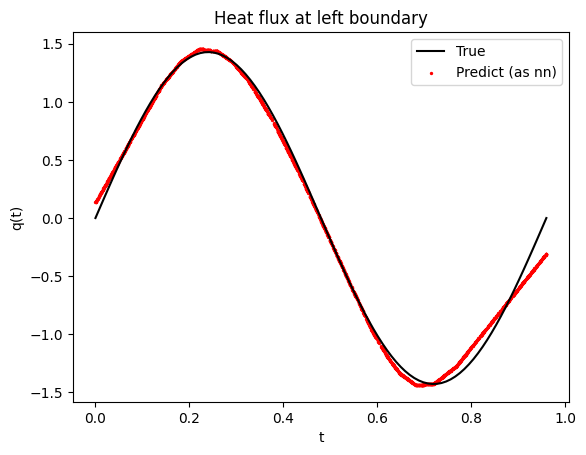

In [29]:
plt.plot(kt*t_fem, q_left_true(t_fem), c='k', label='True')
plt.scatter(t_bc_l.detach().cpu().numpy(),  model.HeatFluxLeft.cpu().detach().numpy(), s=2, c='r', label=f'Predict (as {model_as})')
plt.xlabel('t')
plt.ylabel('q(t)')
plt.title('Heat flux at left boundary')
plt.legend()
plt.show()

## Loss functions

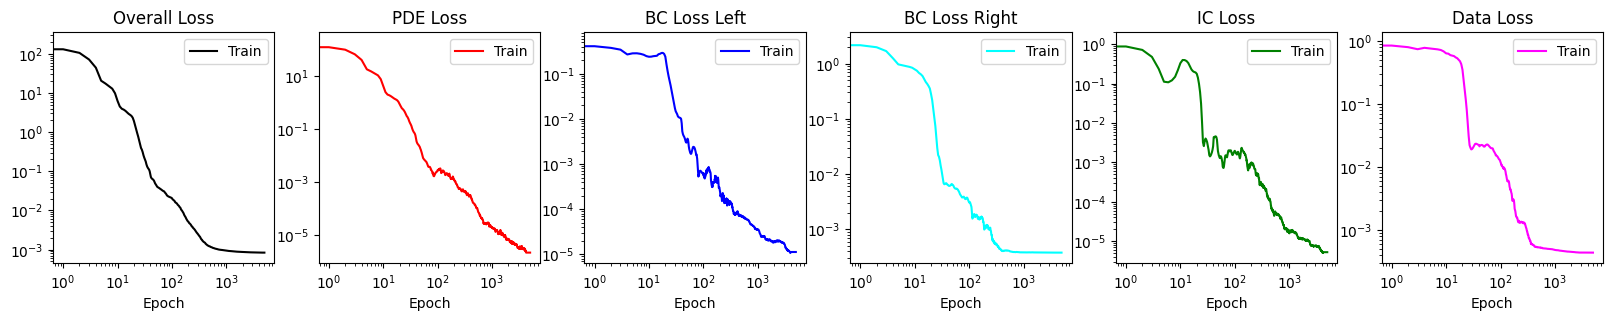

In [30]:
# Evolution of the loss function
loss_train_list = [loss_train, loss_train_dom, loss_train_bc_l, loss_train_bc_r, loss_train_ic]
colors = ['black', 'red', 'blue', 'cyan', 'green']
titles = ['Overall Loss', 'PDE Loss', 'BC Loss Left', 'BC Loss Right', 'IC Loss']
if isData:
    loss_train_list.append(loss_train_data)
    colors.append('magenta')
    titles.append('Data Loss')

fig, ax = plt.subplots(1, len(loss_train_list), figsize=(20, 3))
for i in range(len(loss_train_list)):
    epochs_train = np.arange(0, len(loss_train_list[i]))
    ax[i].loglog(epochs_train, loss_train_list[i], color=colors[i], label='Train')
    ax[i].set_xlabel('Epoch')
    ax[i].set_title(titles[i])
    ax[i].legend()
plt.show()

## Prediction

In [31]:
# Definition of tensors from the testing points for evaluating the trained PINN
pt_x = torch.from_numpy(x_test).float()
pt_t = torch.from_numpy(t_test).float()

In [32]:
# Predicted solution
X_pred = torch.cat([kx*pt_x, kt*pt_t], axis=1).to(device)
Tpred = model(X_pred).data.cpu().numpy()
ms_Tpred = DT * Tpred.reshape(ms_x.shape)

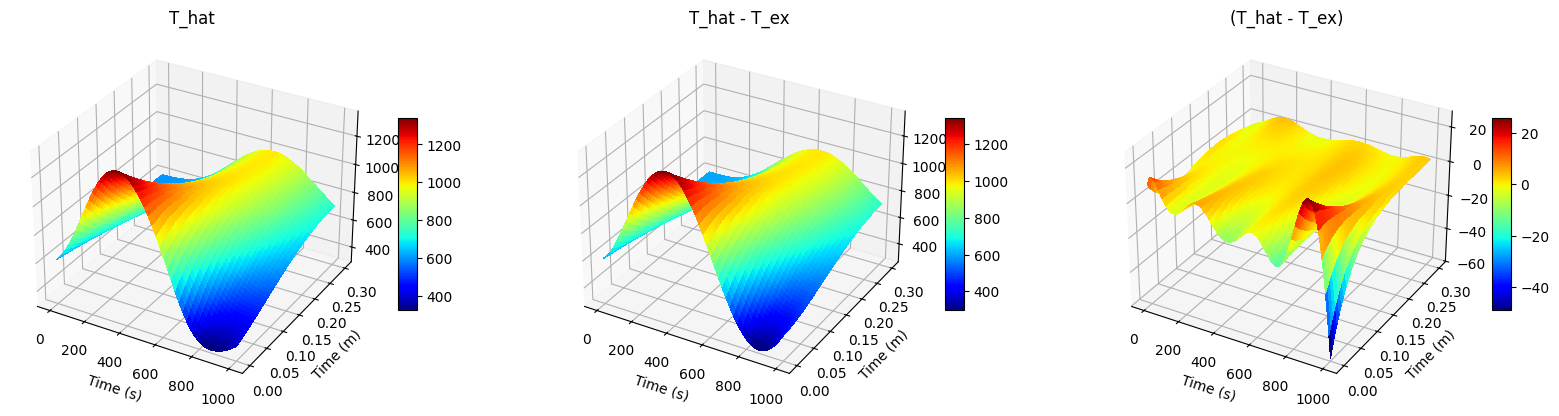

In [33]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5), subplot_kw=dict(projection='3d'))
ax = axs[0]
surf = ax.plot_surface(ms_t, ms_x, ms_Tpred, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Time (m)')
ax.set_title('T_hat')
ax = axs[1]
surf = ax.plot_surface(ms_t, ms_x, TT.T, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Time (m)')
ax.set_title('T_hat - T_ex')
ax = axs[2]
surf = ax.plot_surface(ms_t, ms_x, (ms_Tpred-TT.T), cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Time (m)')
ax.set_title('(T_hat - T_ex)')
plt.show()

In [38]:
t_right = datasets["BoundaryConditionsRight"][:][0][:, 1:2]
T_right = datasets["BoundaryConditionsRight"][:][1]
T_pred_right = model(datasets["BoundaryConditionsRight"][:][0])

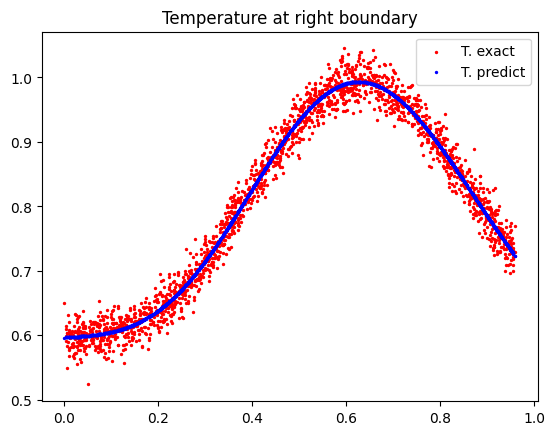

In [39]:
plt.scatter(t_right.detach().cpu().numpy(), T_right.detach().cpu().numpy(), s=2, c='r', label='T. exact')
plt.scatter(t_right.detach().cpu().numpy(), T_pred_right.detach().cpu().numpy(), s=2, c='b', label='T. predict')
plt.title('Temperature at right boundary')
plt.legend()
plt.show()

In [40]:
t_left = datasets["BoundaryConditionsLeft"][:][0][:, 1:2]
T_pred_left = model(datasets["BoundaryConditionsLeft"][:][0])

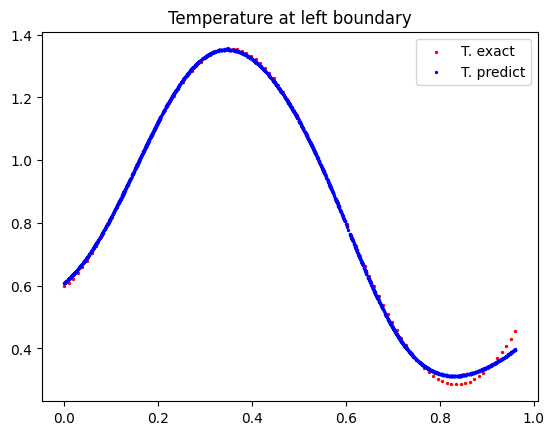

In [41]:
plt.scatter(kt*t_fem, 1/DT*TT[0, :], s=2, c='r', label='T. exact')
plt.scatter(t_left.detach().cpu().numpy(), T_pred_left.detach().cpu().numpy(), s=2, c='b', label='T. predict')
plt.title('Temperature at left boundary')
plt.legend()
plt.show()

In [42]:
x_ini = datasets['InitialCondition'][:][0][:, 0:1]
T_pred_ini = model(datasets['InitialCondition'][:][0])

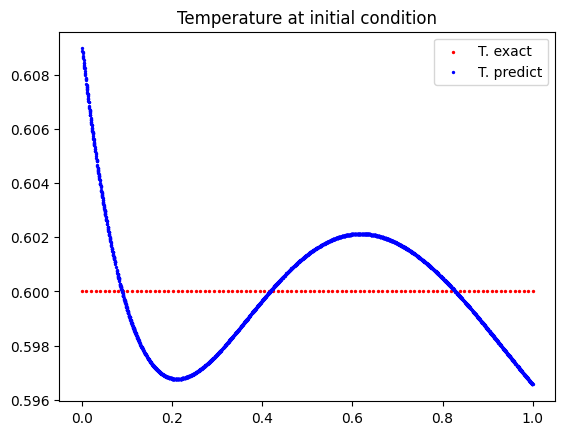

In [43]:
plt.scatter(kx*x_fem, 1/DT*TT[:, 0], s=2, c='r', label='T. exact')
plt.scatter(x_ini.detach().cpu().numpy(), T_pred_ini.detach().cpu().numpy(), s=2, c='b', label='T. predict')
plt.title('Temperature at initial condition')
plt.legend()
plt.show()

In [44]:
X_raw = (datasets["BoundaryConditionsLeft"][:][0])
y = (datasets["BoundaryConditionsLeft"][:][1]).to(device)
X = X_raw.to(device).clone().detach().requires_grad_(True)
T = model(X)

k_model = model.ThermalConductivity
q_left = model.HeatFluxLeft  # ← should be computed inside closure, avoid reuse

Tx = torch.autograd.grad(
    T, X,
    create_graph=True,
    grad_outputs=torch.ones_like(T),
    retain_graph=True
)[0][:, 0:1].clone()

residue = k_model * Tx + q_left

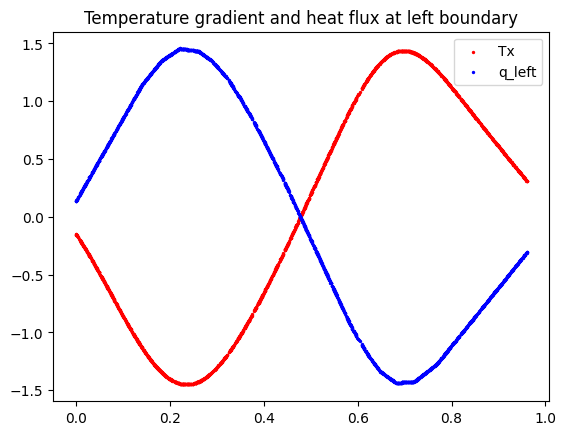

In [45]:
plt.scatter(X[:, 1].detach().cpu().numpy(), Tx.detach().cpu().numpy(), s=2, c='r', label='Tx')
plt.scatter(X[:, 1].detach().cpu().numpy(), q_left.detach().cpu().numpy(), s=2, c='b', label='q_left')
plt.title("Temperature gradient and heat flux at left boundary")
plt.legend()
plt.show()

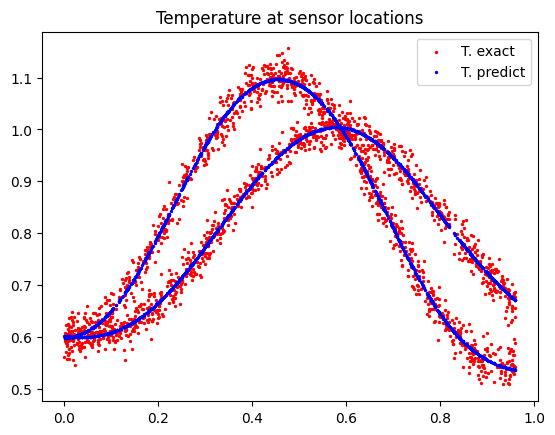

In [46]:
if isData:
    X_sensors = datasets['LabelledData'][:][0].to(device)
    y_sensors = datasets['LabelledData'][:][1]
    T_sensors = model(X_sensors)
    plt.scatter(X_sensors[:, 1].detach().cpu().numpy(), y_sensors.detach().cpu().numpy(), s=2, c='r', label='T. exact')
    plt.scatter(X_sensors[:, 1].detach().cpu().numpy(), T_sensors.detach().cpu().numpy(), s=2, c='b', label='T. predict')
    plt.title('Temperature at sensor locations')
    plt.legend()
    plt.show()